# Summer School UPC
## Febrero 2026

# Análisis Inteligente de Datos


## Docente: PhD. Débora Chan

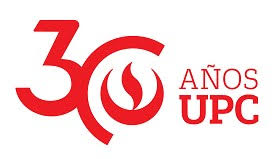

# Análisis de Componentes Principales

En este primer ejemplo vamos a usar el conjunto de datos Iris de Fisher que contiene cuatro mediciones sobre cada lirio y una etiqueta con la especie de lirio.
Hay tres tipos de variedades o especies que se conocen como Virgínica, Setosa y Versicolor.

Las medidas registradas son: ancho y longitud del pétalo y del sépalo de cada flor.

Lo interesante es que además de ser diferentes las flores en la magnitud de estas medidas por especie, también lo son en la forma en que se correlacionan estas medidas en cada especie.


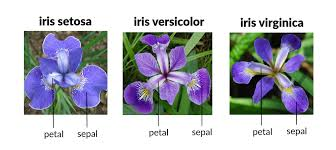

# Inspeccionamos las variables por especie

In [4]:
import altair as alt
alt.data_transformers.disable_max_rows()

import warnings
warnings.filterwarnings(
    "ignore",
    message=".*convert_dtype parameter is deprecated.*",
    category=FutureWarning
)


   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


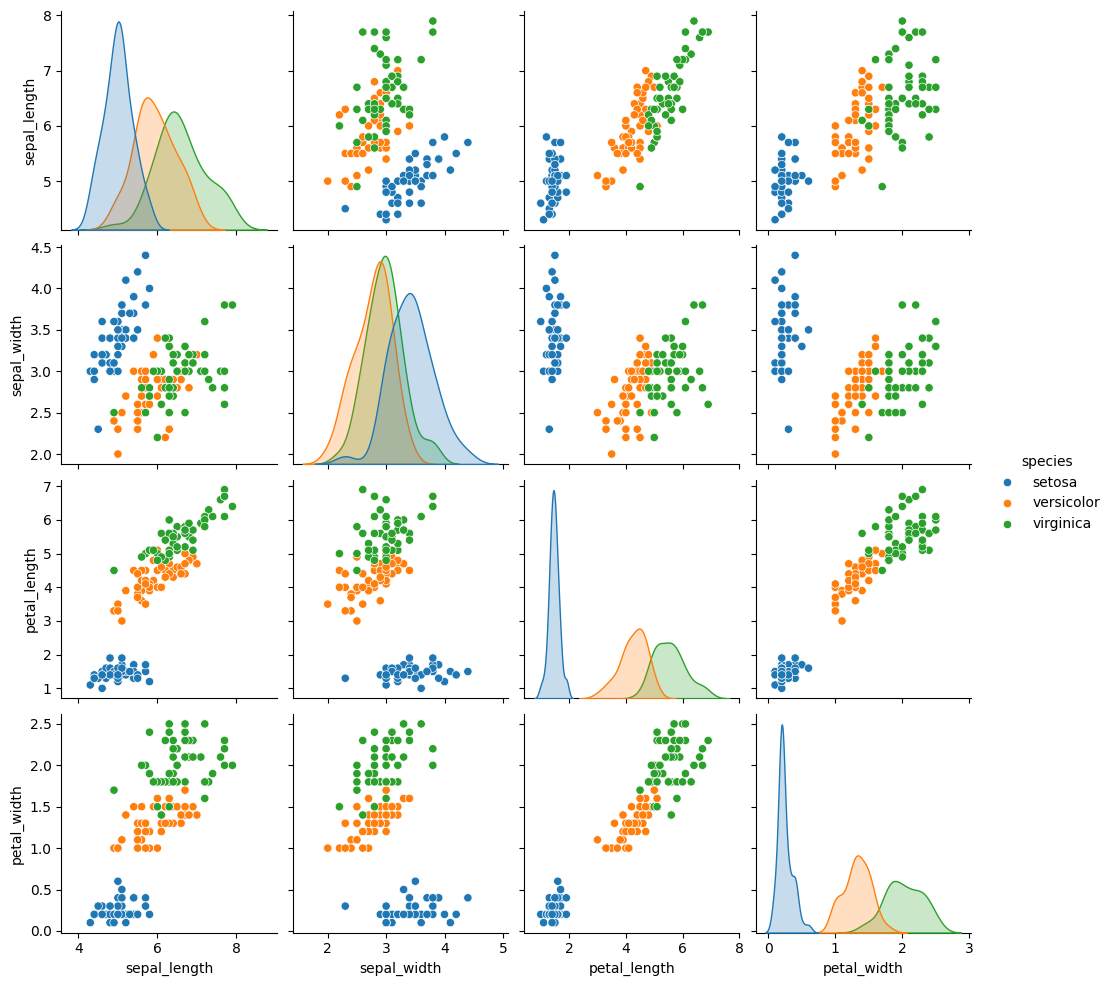

In [5]:
import seaborn as sns
iris=sns.load_dataset("iris")
print(iris.head())
# sale sepal_length  sepal_width  petal_length  petal_width species
corr=sns.pairplot(iris,hue='species', height=2.5)


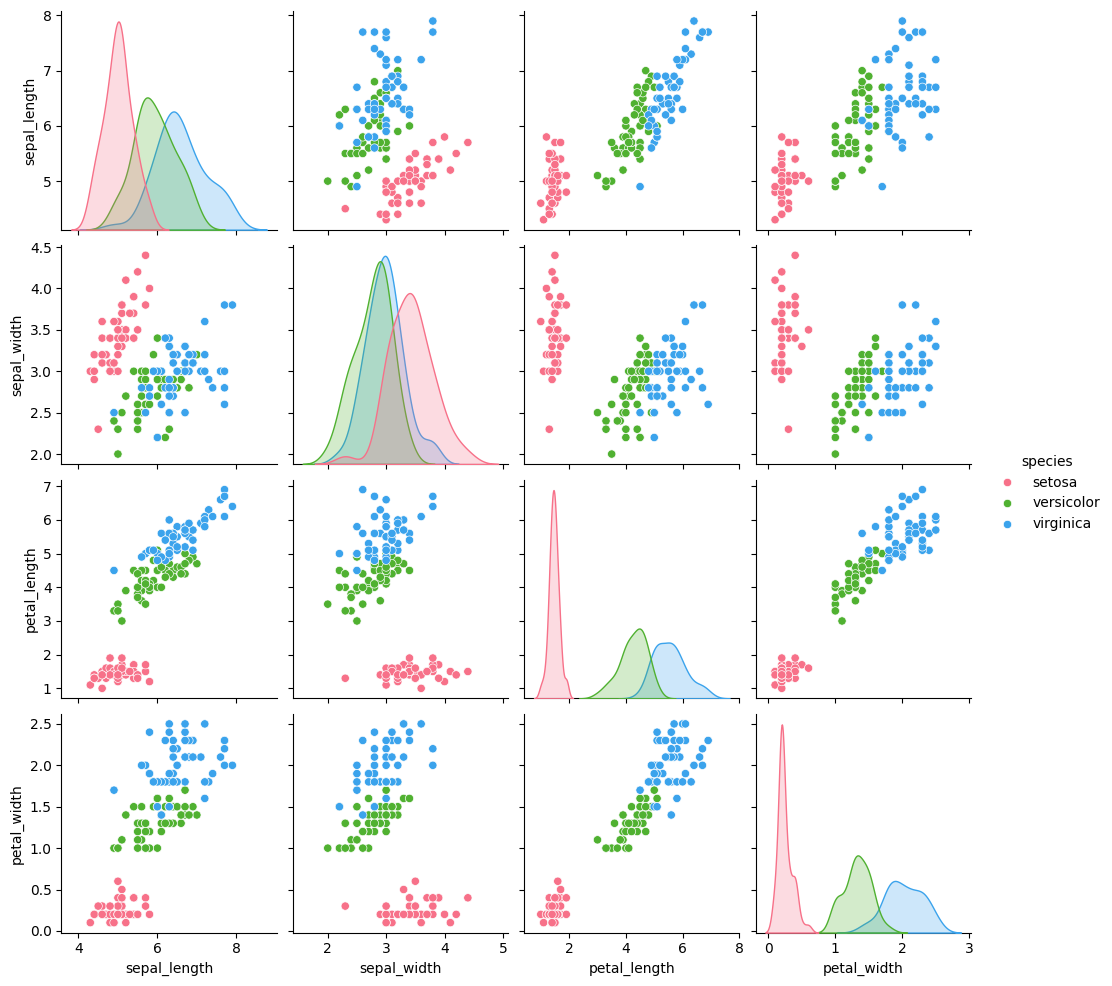

In [6]:
g = sns.pairplot(iris, hue="species", palette="husl")


## Ahora miramos los datos sin distinguir entre las especies

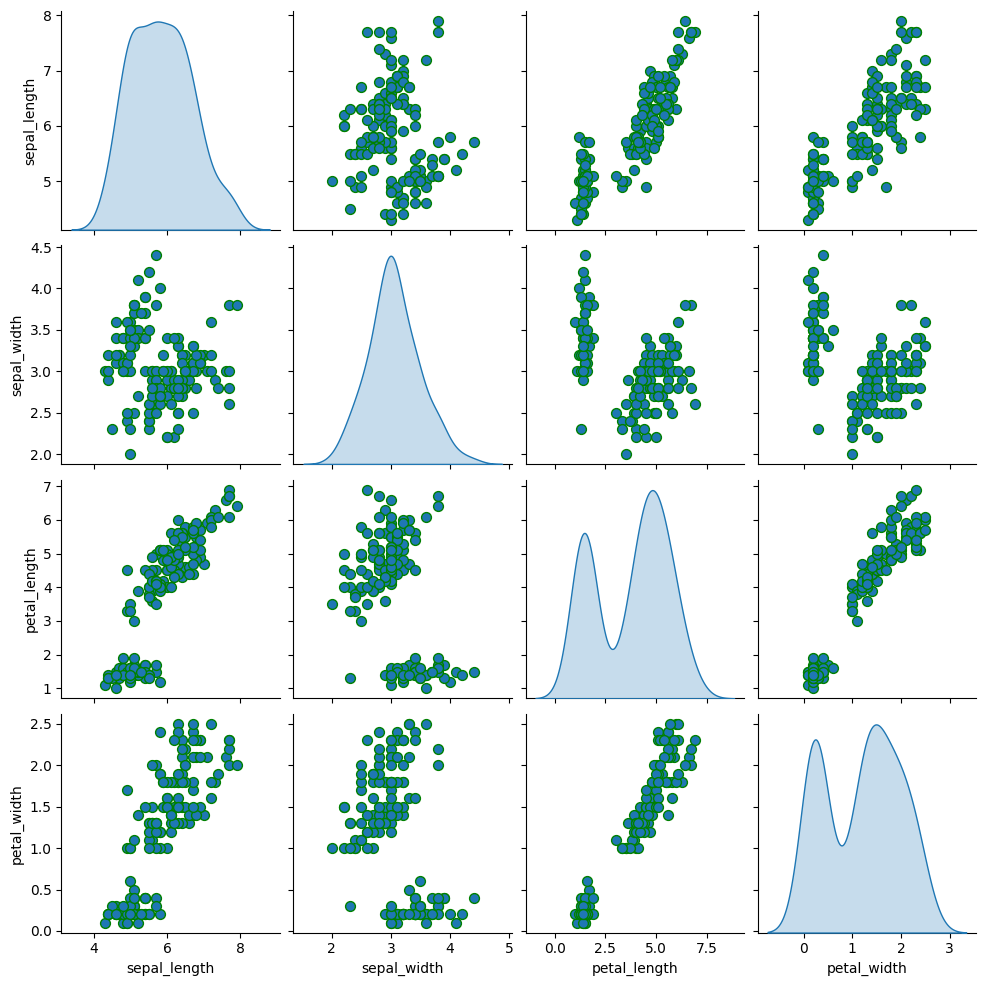

In [7]:
g = sns.pairplot(iris, diag_kind="kde", markers="o",
                 plot_kws=dict(s=50, edgecolor="g", linewidth=1),
                 diag_kws=dict(fill=True))

## Ahora veamos si es posible hallar asociaciones lineales entre las variables (sin distinguir especies)

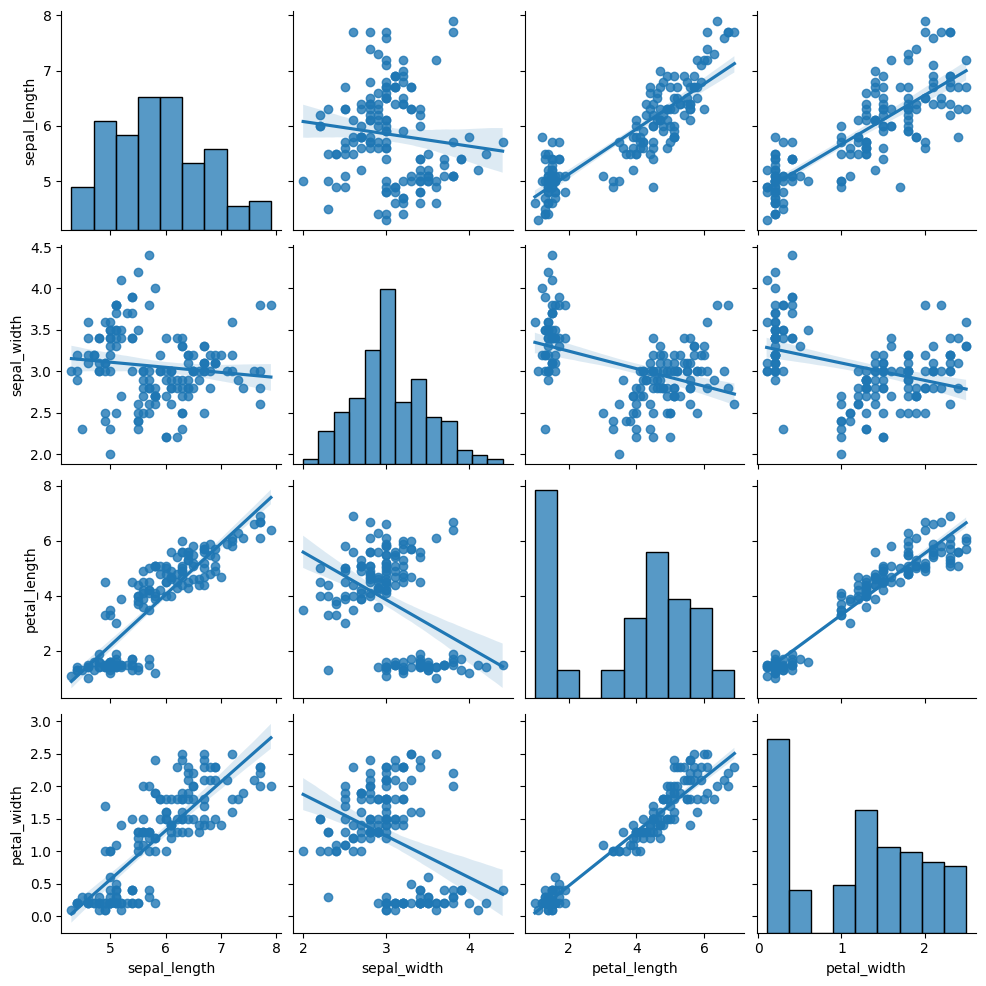

In [8]:
g = sns.pairplot(iris, kind="reg")

## Comparemos la dirección e intensidad de la asociación entre variables

In [9]:
import matplotlib.pyplot as plt

f = plt.figure(figsize=(14,14))
plt.matshow(iris.corr(), fignum=f.number)
plt.xticks(range(iris.shape[1]), iris.columns, fontsize=14)
plt.yticks(range(iris.shape[1]), iris.columns, fontsize=14)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=14)
plt.xticks(range(iris.shape[1]), iris.columns, fontsize=14,rotation=20)
plt.yticks(range(iris.shape[1]), iris.columns, fontsize=14,rotation=-20)



ValueError: could not convert string to float: 'setosa'

<Figure size 1400x1400 with 0 Axes>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
%matplotlib inline

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"


df = pd.read_csv(url, names=['lng sepalo','anch sepalo','lng petalo','anch petalo','especie'])

df.tail()

,lng sepalo,anch sepalo,lng petalo,anch petalo,especie
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [ ]:
# Se divide la matriz del dataset en dos partes

X = df.iloc[:,0:4].values
# la submatriz x contiene los valores de las primeras 4 columnas del dataframe y todas las filas

y = df.iloc[:,4].values
# El vector y contiene los valores de la 4 columna (especie)para todas las filas

In [ ]:
#Aplicamos una transformación de los datos para poder aplicar las propiedades de la distribución normal

from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(X)

In [ ]:
# Calculamos la matriz de covarianza


import numpy as np
from IPython.display import display, Math

cov = np.cov(X_std.T)

def show_pmatrix(A, decimals=3):
    rows = []
    for row in A:
        rows.append(" & ".join(f"{x:.{decimals}f}" for x in row))  # <-- separador de columnas
    body = r" \\ ".join(rows)  # <-- separador de filas
    display(Math(r"\left(\begin{array}{" + "c"*A.shape[1] + "}" + body + r"\end{array}\right)"))

show_pmatrix(cov, decimals=3)


<IPython.core.display.Math object>

In [ ]:
#Calculamos los autovalores y autovectores de la matriz y los mostramos
import numpy as np
import pandas as pd
from IPython.display import display, Math

# 1) Covarianza y autodescomposición
cov_mat = np.cov(X_std.T)
eig_vals, eig_vecs = np.linalg.eig(cov_mat)

# 2) Ordenar de mayor a menor autovalor
idx = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[idx]
eig_vecs = eig_vecs[:, idx]   # (IMPORTANTE) ordenar columnas

# 3) Varianza explicada
explained_var = eig_vals / eig_vals.sum()
cum_explained_var = np.cumsum(explained_var)




In [ ]:
# 4) Tabla resumen
df = pd.DataFrame({
    "Componente": np.arange(1, len(eig_vals) + 1),
    "Autovalor": eig_vals.real,
    "Varianza explicada (%)": (100 * explained_var.real),
    "Acumulada (%)": (100 * cum_explained_var.real),
})

display(df.style.format({
    "Autovalor": "{:.6f}",
    "Varianza explicada (%)": "{:.2f}",
    "Acumulada (%)": "{:.2f}",
}))



,Componente,Autovalor,Varianza explicada (%),Acumulada (%)
0,1,2.930354,72.77,72.77
1,2,0.927404,23.03,95.80
2,3,0.148342,3.68,99.48
3,4,0.020746,0.52,100.00


In [ ]:
# 5) Mostrar autovectores como vectores columna (LaTeX)
def show_col_vector(v, name="v", decimals=4):
    v = np.real(v)  # por si sale algo tipo 0+0j
    body = r" \\ ".join(f"{x:.{decimals}f}" for x in v)
    display(Math(rf"{name}=\begin{{pmatrix}}{body}\end{{pmatrix}}"))

for i in range(eig_vecs.shape[1]):
    show_col_vector(eig_vecs[:, i], name=rf"v_{{{i+1}}}", decimals=4)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
#  Hacemos una lista de parejas (autovector, autovalor) 
eig_pairs = [(np.abs(eig_vals[i]), eig_vecs[:,i]) for i in range(len(eig_vals))]

# Ordenamos estas parejas den orden descendiente con la función sort
eig_pairs.sort(key=lambda x: x[0], reverse=True)

# Visualizamos la lista de autovalores en orden desdenciente
print('Autovalores en orden descendiente:')
for i in eig_pairs:
    print(round(i[0],4))

Autovalores en orden descendiente:
2.9304
0.9274
0.1483
0.0207


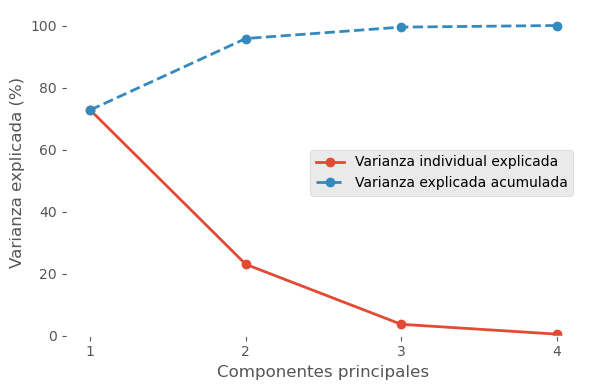

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Varianza explicada (en %)
eig_vals_sorted = np.sort(eig_vals)[::-1]
var_exp = (eig_vals_sorted / eig_vals_sorted.sum()) * 100
cum_var_exp = np.cumsum(var_exp)

x = np.arange(1, len(var_exp) + 1)


with plt.style.context('ggplot'):
    fig, ax = plt.subplots(figsize=(6, 4))

    ax.plot(x, var_exp, marker='o', linewidth=2, label='Varianza individual explicada')
    ax.plot(x, cum_var_exp, marker='o', linestyle='--', linewidth=2, label='Varianza explicada acumulada')

    ax.set_xlabel('Componentes principales')
    ax.set_ylabel('Varianza explicada (%)')
    ax.set_xticks(x)
    ax.set_ylim(0, 105)
    ax.legend(loc='best')

    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')   # <-- saca el gris del área del gráfico

    plt.tight_layout()
    plt.show()


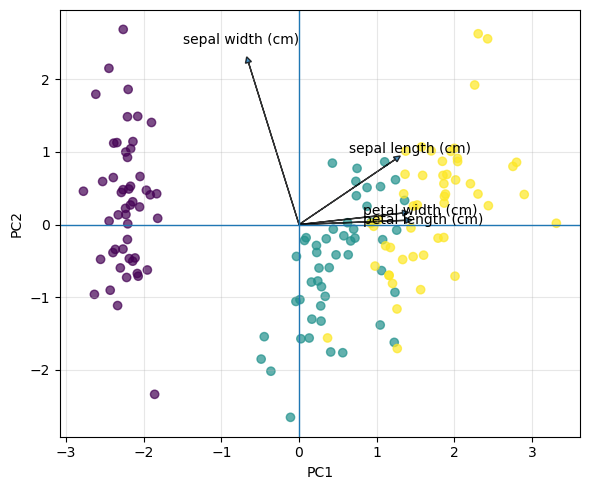

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

iris = datasets.load_iris()
X = iris.data
y = iris.target
labels = iris.feature_names  # nombres reales

# Escalado
X_std = StandardScaler().fit_transform(X)

# PCA (2 componentes)
pca = PCA(n_components=2)
scores = pca.fit_transform(X_std)          # puntos
loadings = pca.components_.T               # (4x2) flechas (variables)

# Escalado para que flechas y puntos convivan bien visualmente
# (factor típico para biplot)
arrow_scale = 2.5

plt.figure(figsize=(6, 5))
plt.scatter(scores[:, 0], scores[:, 1], c=y, alpha=0.7)

# Flechas + etiquetas
for i, name in enumerate(labels):
    plt.arrow(0, 0,
              loadings[i, 0] * arrow_scale,
              loadings[i, 1] * arrow_scale,
              head_width=0.08, head_length=0.08,
              length_includes_head=True, alpha=0.8)
    plt.text(loadings[i, 0] * arrow_scale * 1.10,
             loadings[i, 1] * arrow_scale * 1.10,
             name, ha='center', va='center')

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
 #!pip install prince
   

In [ ]:

import prince  
 

X, y = datasets.load_iris(return_X_y=True)
X = pd.DataFrame(data=X, columns=['Sepal length', 'Sepal width', 'Petal length', 'Petal width'])
y = pd.Series(y).map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})
X.head()

,Sepal length,Sepal width,Petal length,Petal width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [1]:
import pandas as pd
import prince
from sklearn import datasets
from IPython.display import display

iris = datasets.load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
species = pd.Categorical.from_codes(iris.target, iris.target_names)

# Poner species como índice (el PCA se hace solo con columnas numéricas)
df.index = pd.Index(species, name="species")

pca = prince.PCA(
    n_components=2,
    rescale_with_mean=True,
    rescale_with_std=True,
    engine="sklearn",
    random_state=42
).fit(df)

chart = pca.plot(
    df,
    x_component=0,
    y_component=1,
    color_rows_by="species",
    show_row_markers=True,
    show_column_markers=True,
    show_row_labels=False,
    show_column_labels=True
)

display(chart)   # <-- IMPORTANTE (no es plt.show())


alt.LayerChart(...)

#<span style="color:darkcyan; font-weight:900;">
Ejemplo Nadadores
</span>



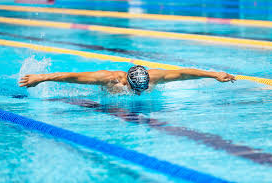

<h3 style="color:darkcyan;">Cargamos la base e inspeccionamos los registros</h3>

In [2]:
import pandas as pd
import numpy as np

df1 = pd.read_csv("C:\\Users\\nanab\\Downloads\\OneDrive_1_2-9-2026\\datos\\nadadores.csv", sep=";")

# Si tenés una columna identificadora (ej: 'nadador' o 'id'), podés usarla como índice:
# df1 = df1.set_index('nadador')

X = df1[['tr1','tr2','tr3','tr4']].copy()

display(df1.head())
print("Shape:", X.shape)
print(X.describe())
print("\n¿Missing?:\n", X.isna().sum())


,Nadador,tr1,tr2,tr3,tr4
0,A,10,10,13,12
1,B,12,12,14,15
2,C,11,10,14,13
3,D,9,9,11,11
4,E,8,8,9,8


Shape: (14, 4)
             tr1        tr2        tr3        tr4
count  14.000000  14.000000  14.000000  14.000000
mean   11.214286  11.214286  11.571429  11.285714
std     2.224983   2.082106   1.910066   2.127786
min     8.000000   8.000000   8.000000   8.000000
25%    10.000000  10.000000  10.250000   9.250000
50%    11.000000  11.000000  11.500000  11.000000
75%    12.750000  12.750000  13.000000  13.000000
max    15.000000  15.000000  14.000000  15.000000

¿Missing?:
 tr1    0
tr2    0
tr3    0
tr4    0
dtype: int64


<h3 style="color:darkcyan;">Estandarizamos los datos y aplicamos PCA</h3>

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

pca = PCA()
scores = pca.fit_transform(X_std)   # coordenadas de los nadadores (individuos)
loadings = pca.components_.T        # (4 x 4) vectores de variables
eig_vals = pca.explained_variance_  # autovalores (en datos estandarizados)
explained = pca.explained_variance_ratio_


<h3 style="color:darkcyan;">Tabla de Resumen: Varianza explicada</h3>

In [ ]:
summary = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(explained))],
    "Autovalor": eig_vals,
    "Varianza explicada (%)": 100*explained,
    "Acumulada (%)": 100*np.cumsum(explained),
})
display(summary.style.format({
    "Autovalor": "{:.4f}",
    "Varianza explicada (%)": "{:.2f}",
    "Acumulada (%)": "{:.2f}",
}))


,PC,Autovalor,Varianza explicada (%),Acumulada (%)
0,PC1,3.1484,73.09,73.09
1,PC2,0.9869,22.91,96.00
2,PC3,0.1306,3.03,99.03
3,PC4,0.0418,0.97,100.00


<h3 style="color:darkcyan;">Screeplot o Gráfico de Sedimentación</h3>

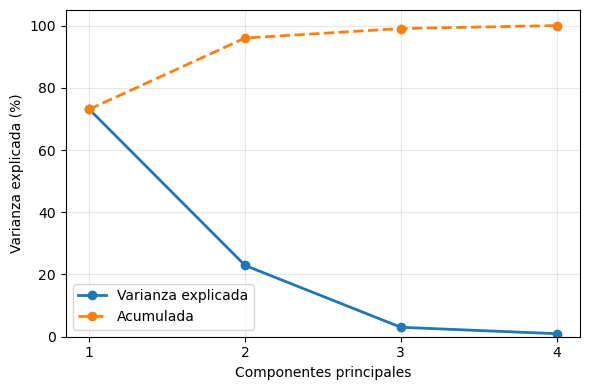

In [ ]:
import matplotlib.pyplot as plt

x = np.arange(1, len(explained)+1)
var_exp = 100*explained
cum_var = 100*np.cumsum(explained)

with plt.style.context('default'):
    plt.figure(figsize=(6,4))
    plt.plot(x, var_exp, marker='o', linewidth=2, label='Varianza explicada')
    plt.plot(x, cum_var, marker='o', linestyle='--', linewidth=2, label='Acumulada')
    plt.xticks(x)
    plt.ylim(0, 105)
    plt.xlabel('Componentes principales')
    plt.ylabel('Varianza explicada (%)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
<h3 style="color:darkcyan;">Importancia de variables en las componentes</h3>

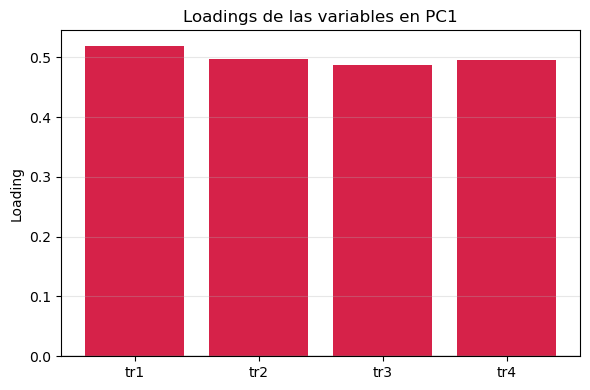

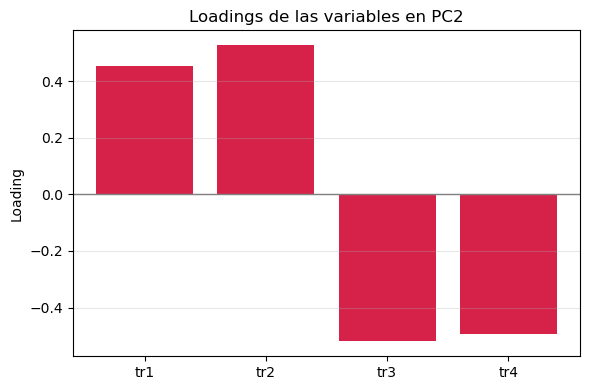

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

loadings = pca.components_.T
features = X.columns.tolist()

features = X.columns.tolist()
loadings_df = pd.DataFrame(loadings[:, :2], index=features, columns=["PC1", "PC2"])

def plot_loadings_bar(loadings_series, title):
    plt.figure(figsize=(6,4))
    x = np.arange(len(loadings_series.index))
    plt.bar(x, loadings_series.values,color="#D62249")
    plt.axhline(0, linewidth=1,color="gray")
    plt.xticks(x, loadings_series.index)
    plt.ylabel("Loading")
    plt.title(title)
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_loadings_bar(loadings_df["PC1"], "Loadings de las variables en PC1")
plot_loadings_bar(loadings_df["PC2"], "Loadings de las variables en PC2")


<h3 style="color:darkcyan;">Visualización de individuos en las componentes</h3>

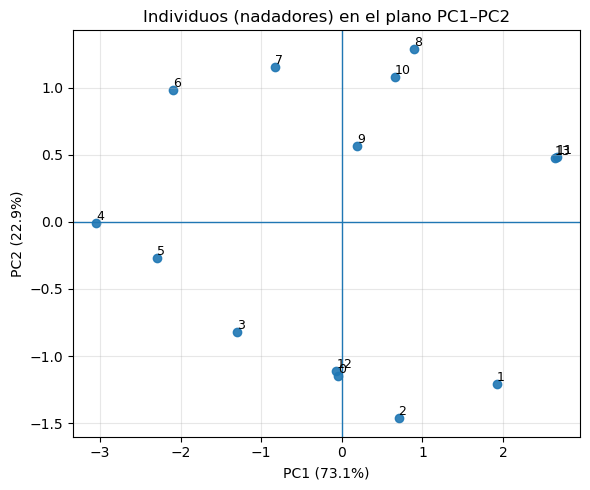

In [ ]:
scores_df = pd.DataFrame(scores[:, :2], columns=["PC1","PC2"], index=X.index)

with plt.style.context('default'):
    plt.figure(figsize=(6,5))
    plt.scatter(scores_df["PC1"], scores_df["PC2"], alpha=0.9)
    
    # Etiquetas (útil con 13 puntos)
    for idx, row in scores_df.iterrows():
        plt.text(row["PC1"], row["PC2"], str(idx), fontsize=9, ha='left', va='bottom')
    
    plt.axhline(0, linewidth=1)
    plt.axvline(0, linewidth=1)
    plt.grid(True, alpha=0.3)
    plt.xlabel(f"PC1 ({var_exp[0]:.1f}%)")
    plt.ylabel(f"PC2 ({var_exp[1]:.1f}%)")
    plt.title("Individuos (nadadores) en el plano PC1–PC2")
    plt.tight_layout()
    plt.show()


<h3 style="color:darkcyan;">BIPLOT</h3>

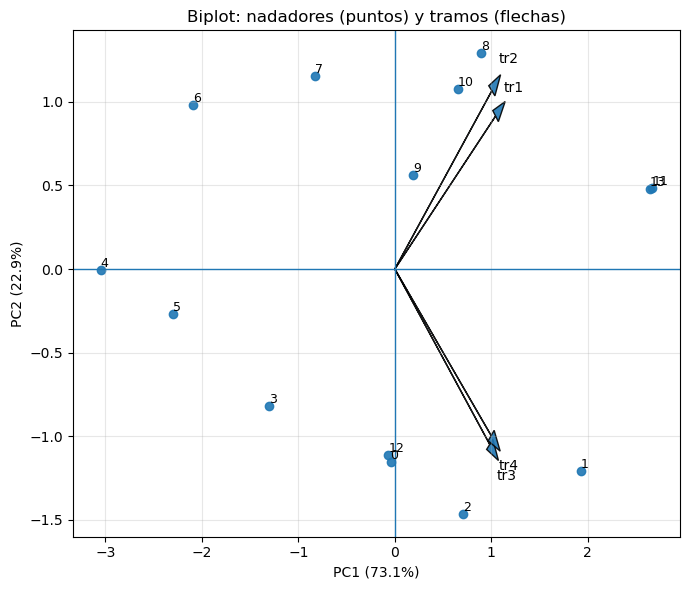

In [ ]:
def biplot(scores_2d, loadings_2d, labels_points=None, labels_vars=None, title="Biplot PC1–PC2"):
    xs = scores_2d[:, 0]
    ys = scores_2d[:, 1]

    # Escala para que entren flechas y puntos en la misma figura (heurística simple)
    scale_x = (xs.max() - xs.min())
    scale_y = (ys.max() - ys.min())
    arrow_scale = 0.8 * min(scale_x, scale_y)

    plt.figure(figsize=(7,6))
    plt.scatter(xs, ys, alpha=0.9)

    # Etiquetas de puntos
    if labels_points is not None:
        for i, lab in enumerate(labels_points):
            plt.text(xs[i], ys[i], str(lab), fontsize=9, ha='left', va='bottom')

    # Flechas de variables
    for i in range(loadings_2d.shape[0]):
        x_arrow = loadings_2d[i, 0] * arrow_scale
        y_arrow = loadings_2d[i, 1] * arrow_scale

        plt.arrow(0, 0, x_arrow, y_arrow,
                  head_width=0.04*arrow_scale, head_length=0.06*arrow_scale,
                  length_includes_head=True, alpha=0.9)

        name = labels_vars[i] if labels_vars is not None else f"Var{i+1}"
        plt.text(x_arrow*1.08, y_arrow*1.08, name, fontsize=10, ha='center', va='center')

    plt.axhline(0, linewidth=1)
    plt.axvline(0, linewidth=1)
    plt.grid(True, alpha=0.3)
    plt.xlabel(f"PC1 ({var_exp[0]:.1f}%)")
    plt.ylabel(f"PC2 ({var_exp[1]:.1f}%)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

biplot(
    scores[:, :2],
    loadings[:, :2],
    labels_points=X.index,      # si tu índice no es nombre, igual sirve (0..12)
    labels_vars=features,
    title="Biplot: nadadores (puntos) y tramos (flechas)"
)


# <h1 style="color:darkcyan;"> Ejemplo USArrests</h1>

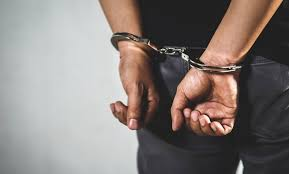

El set de datos USArrests contiene el porcentaje de asaltos (Assault), asesinatos (Murder) y secuestros (Rape) por cada 100,000 habitantes para cada uno de los 50 estados de USA (1973). Además, también incluye el porcentaje de la población de cada estado que vive en zonas rurales (UrbanPoP).

In [ ]:
# Tratamiento de datos
# ==============================================================================
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
import matplotlib.font_manager
from matplotlib import style
style.use('ggplot') or plt.style.use('ggplot')

# Preprocesado y modelado
# ==============================================================================
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import scale

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')


In [ ]:
# Lectura de datos
# ==============================================================================
USArrests = sm.datasets.get_rdataset("USArrests", "datasets")
datos = USArrests.data
datos.head(4)

,Murder,Assault,UrbanPop,Rape
rownames,,,,
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5


<h3 style="color:darkcyan;">Exploración Inicial de la Base</h3>

In [ ]:
print('----------------------')
print('Media de cada variable')
print('----------------------')
datos.mean(axis=0)

----------------------
Media de cada variable
----------------------


Murder        7.788
Assault     170.760
UrbanPop     65.540
Rape         21.232
dtype: float64

In [ ]:
print('-------------------------')
print('Varianza de cada variable')
print('-------------------------')
datos.var(axis=0)

-------------------------
Varianza de cada variable
-------------------------


Murder        18.970465
Assault     6945.165714
UrbanPop     209.518776
Rape          87.729159
dtype: float64

En este ejemplo se aprecia la importancia de estandarizar las variables para que tengan media cero y desviación estándar de uno antes de realizar el estudio PCA, la variable Assault, que tiene una media y dispersión muy superior al resto, dominará la mayoría de las componentes principales.

In [ ]:
# Entrenamiento modelo PCA con escalado de los datos
# ==============================================================================
pca_pipe = make_pipeline(StandardScaler(), PCA())
pca_pipe.fit(datos)

# Se extrae el modelo entrenado del pipeline
modelo_pca = pca_pipe.named_steps['pca']

Una vez entrenado el objeto PCA, pude accederse a toda la información de las componentes creadas.

components_ contiene el valor de los loadings ϕ que definen cada componente (eigenvector). Las filas se corresponden con las componentes principals (ordenadas de mayor a menor varianza explicada). Las filas se corresponden con las variables de entrada.


In [ ]:
# Se convierte el array a dataframe para añadir nombres a los ejes
# ==============================================================================
pd.DataFrame(
    data    = modelo_pca.components_,
    columns = datos.columns,
    index   = ['PC1', 'PC2', 'PC3', 'PC4']
)

,Murder,Assault,UrbanPop,Rape
PC1,0.535899,0.583184,0.278191,0.543432
PC2,-0.418181,-0.187986,0.872806,0.167319
PC3,-0.341233,-0.268148,-0.378016,0.817778
PC4,-0.649228,0.743407,-0.133878,-0.089024


Analizar con detalle el vector de loadings que forma cada componente puede ayudar a interpretar qué tipo de información recoge cada una de ellas. Por ejemplo, la primera componente es el resultado de la siguiente combinación lineal de las variables originales:
PC1=0.535899 Murder+0.583184 Assault+0.278191 UrbanPop+0.543432 Rape

Los pesos asignados en la primera componente a las variables Assault, Murder y Rape son aproximadamente iguales entre ellos y superiores al asignado a UrbanPoP. Esto significa que la primera componente recoge mayoritariamente la información correspondiente a los delitos. En la segunda componente, es la variable UrbanPoP es la que tiene con diferencia mayor peso, por lo que se corresponde principalmente con el nivel de urbanización del estado. Si bien en este ejemplo la interpretación de las componentes es bastante clara, no en todos los casos ocurre lo mismo, sobre todo a medida que aumenta el número de variables.

In [ ]:
loadings = pd.DataFrame(
    data=modelo_pca.components_,
    columns=datos.columns,
    index=['PC1','PC2','PC3','PC4']
)


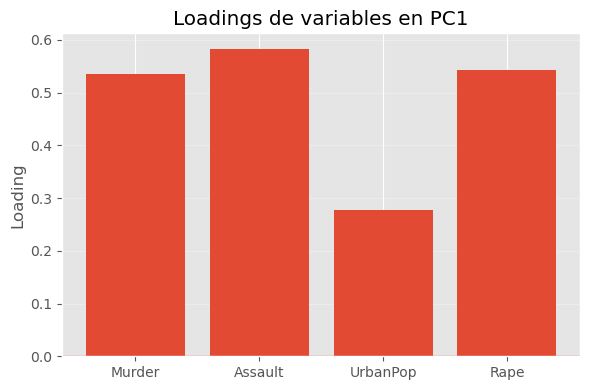

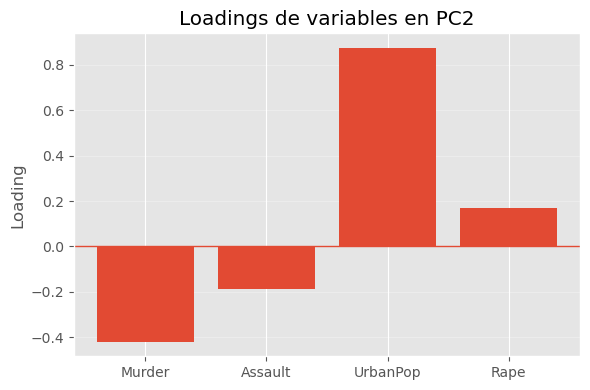

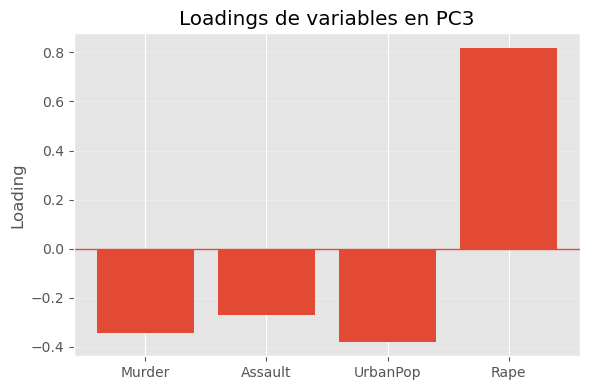

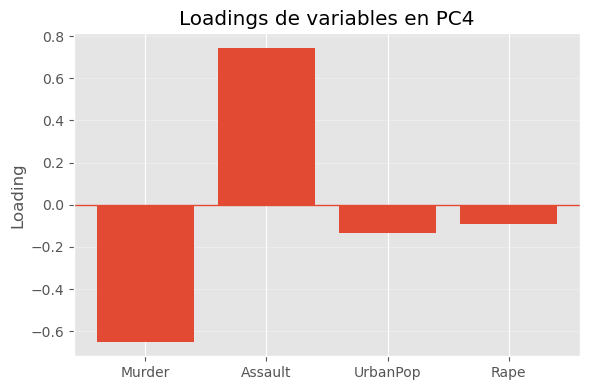

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

for pc in loadings.index:
    plt.figure(figsize=(6,4))
    vals = loadings.loc[pc]

    x = np.arange(len(vals.index))
    plt.bar(x, vals.values)

    plt.axhline(0, linewidth=1)
    plt.xticks(x, vals.index)
    plt.ylabel("Loading")
    plt.title(f"Loadings de variables en {pc}")
    plt.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()


----------------------------------------------------
Porcentaje de varianza explicada por cada componente
----------------------------------------------------
[0.62006039 0.24744129 0.0891408  0.04335752]


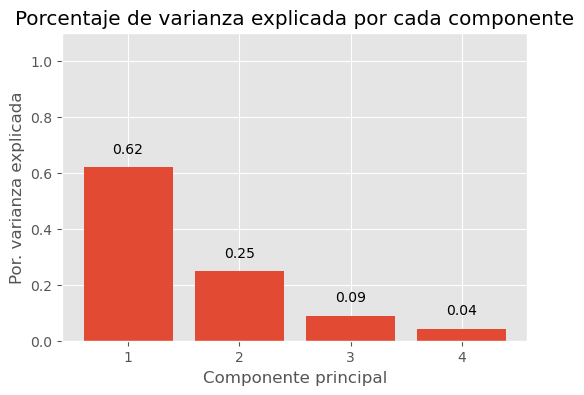

In [ ]:
# Porcentaje de varianza explicada por cada componente
# ==============================================================================
print('----------------------------------------------------')
print('Porcentaje de varianza explicada por cada componente')
print('----------------------------------------------------')
print(modelo_pca.explained_variance_ratio_)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))
ax.bar(
    x      = np.arange(modelo_pca.n_components_) + 1,
    height = modelo_pca.explained_variance_ratio_
)

for x, y in zip(np.arange(len(datos.columns)) + 1, modelo_pca.explained_variance_ratio_):
    label = round(y, 2)
    ax.annotate(
        label,
        (x,y),
        textcoords="offset points",
        xytext=(0,10),
        ha='center'
    )

ax.set_xticks(np.arange(modelo_pca.n_components_) + 1)
ax.set_ylim(0, 1.1)
ax.set_title('Porcentaje de varianza explicada por cada componente')
ax.set_xlabel('Componente principal')
ax.set_ylabel('Por. varianza explicada');


------------------------------------------
Porcentaje de varianza explicada acumulada
------------------------------------------
[0.62006039 0.86750168 0.95664248 1.        ]


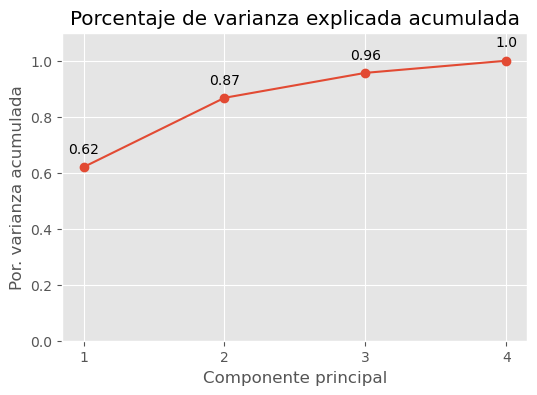

In [ ]:
# Porcentaje de varianza explicada acumulada
# ==============================================================================
prop_varianza_acum = modelo_pca.explained_variance_ratio_.cumsum()
print('------------------------------------------')
print('Porcentaje de varianza explicada acumulada')
print('------------------------------------------')
print(prop_varianza_acum)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))
ax.plot(
    np.arange(len(datos.columns)) + 1,
    prop_varianza_acum,
    marker = 'o'
)

for x, y in zip(np.arange(len(datos.columns)) + 1, prop_varianza_acum):
    label = round(y, 2)
    ax.annotate(
        label,
        (x,y),
        textcoords="offset points",
        xytext=(0,10),
        ha='center'
    )
    
ax.set_ylim(0, 1.1)
ax.set_xticks(np.arange(modelo_pca.n_components_) + 1)
ax.set_title('Porcentaje de varianza explicada acumulada')
ax.set_xlabel('Componente principal')
ax.set_ylabel('Por. varianza acumulada');


Una vez entrenado el modelo, con el método transform() se puede reducir la dimensionalidad de nuevas observaciones proyectándolas en el espacio definido por las componentes. Es decir calcula los scores de las observaciones.

In [ ]:
# Proyección de las observaciones de entrenamiento
# ==============================================================================
proyecciones = pca_pipe.transform(X=datos)
proyecciones = pd.DataFrame(
    proyecciones,
    columns = ['PC1', 'PC2', 'PC3', 'PC4'],
    index   = datos.index
)
proyecciones.head()

,PC1,PC2,PC3,PC4
rownames,,,,
Alabama,0.985566,-1.133392,-0.444269,-0.156267
Alaska,1.950138,-1.073213,2.040003,0.438583
Arizona,1.763164,0.745957,0.054781,0.834653
Arkansas,-0.141420,-1.119797,0.114574,0.182811
California,2.523980,1.542934,0.598557,0.341996


In [ ]:
proyecciones = np.dot(modelo_pca.components_, scale(datos).T)
proyecciones = pd.DataFrame(proyecciones, index = ['PC1', 'PC2', 'PC3', 'PC4'])
proyecciones = proyecciones.transpose().set_index(datos.index)
proyecciones.head()

,PC1,PC2,PC3,PC4
rownames,,,,
Alabama,0.985566,-1.133392,-0.444269,-0.156267
Alaska,1.950138,-1.073213,2.040003,0.438583
Arizona,1.763164,0.745957,0.054781,0.834653
Arkansas,-0.141420,-1.119797,0.114574,0.182811
California,2.523980,1.542934,0.598557,0.341996


In [ ]:
# Recostruccion de las proyecciones
# ==============================================================================
recostruccion = pca_pipe.inverse_transform(X=proyecciones)
recostruccion = pd.DataFrame(
                    recostruccion,
                    columns = datos.columns,
                    index   = datos.index
)
print('------------------')
print('Valores originales')
print('------------------')
display(recostruccion.head())

print('---------------------')
print('Valores reconstruidos')
print('---------------------')
display(datos.head())

------------------
Valores originales
------------------


,Murder,Assault,UrbanPop,Rape
rownames,,,,
Alabama,13.2,236.0,58.0,21.2
Alaska,10.0,263.0,48.0,44.5
Arizona,8.1,294.0,80.0,31.0
Arkansas,8.8,190.0,50.0,19.5
California,9.0,276.0,91.0,40.6


---------------------
Valores reconstruidos
---------------------


,Murder,Assault,UrbanPop,Rape
rownames,,,,
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


def biplot_pca_blanco(modelo_pca, X_std, feature_names, obs_names,
                      pcx=1, pcy=2, figsize=(12,8), label_size=8, arrow_frac=0.7):
    # 1) Reset total de estilo (quita ggplot/seaborn) + fondo blanco
    plt.rcdefaults()
    plt.style.use("default")
    plt.rcParams["figure.facecolor"] = "white"
    plt.rcParams["axes.facecolor"] = "white"

    scores = modelo_pca.transform(X_std)
    xs = scores[:, pcx-1]
    ys = scores[:, pcy-1]

    loadings = modelo_pca.components_.T
    lx = loadings[:, pcx-1]
    ly = loadings[:, pcy-1]

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    # Puntos
    ax.scatter(xs, ys, alpha=0.85, zorder=2)

    # Etiquetas (estados)
    for i, name in enumerate(obs_names):
        ax.text(xs[i], ys[i], str(name), fontsize=label_size,
                ha="left", va="bottom", zorder=3)

    # 2) Escala automática de flechas en función del rango de los scores
    rx = xs.max() - xs.min()
    ry = ys.max() - ys.min()
    scale = arrow_frac * min(rx, ry)  # tamaño “razonable” en el plano

    # Flechas + etiquetas de variables
    for j, var in enumerate(feature_names):
        dx = lx[j] * scale
        dy = ly[j] * scale

        ax.annotate(
            "", xy=(dx, dy), xytext=(0, 0),
            arrowprops=dict(arrowstyle="->", lw=2, alpha=0.9),
            zorder=4
        )
        ax.text(dx*1.10, dy*1.10, var, fontsize=11,
                ha="center", va="center", zorder=5)

    evr = modelo_pca.explained_variance_ratio_
    ax.axhline(0, linewidth=1, zorder=1)
    ax.axvline(0, linewidth=1, zorder=1)

    ax.grid(True, alpha=0.25)
    ax.set_xlabel(f"PC{pcx} ({evr[pcx-1]*100:.1f}%)")
    ax.set_ylabel(f"PC{pcy} ({evr[pcy-1]*100:.1f}%)")
    ax.set_title(f"Biplot (PC{pcx} vs PC{pcy})")

    plt.tight_layout()
    plt.show()



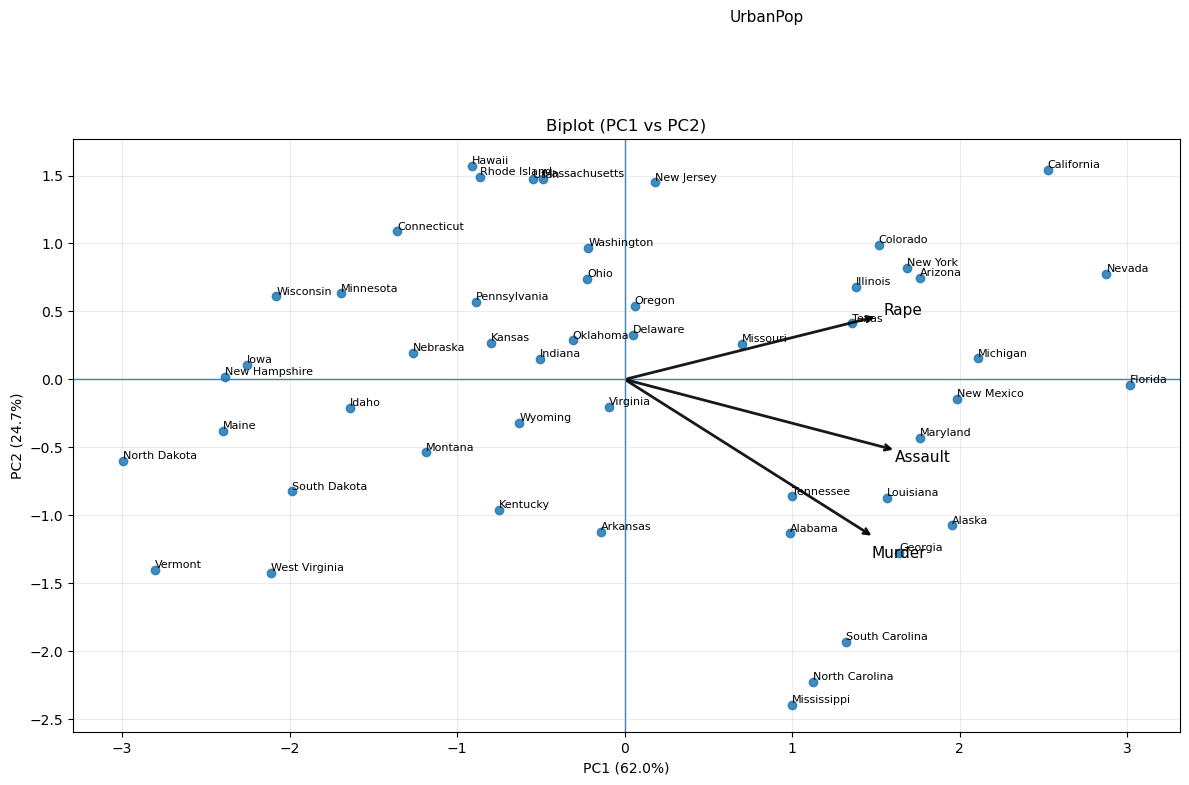

In [ ]:
feature_names = list(datos.columns)
obs_names = list(datos.index)

biplot_pca_blanco(modelo_pca, X_std, feature_names, obs_names,
                  figsize=(12,8), label_size=8, arrow_frac=0.7)
